In [20]:
import numpy as np

# ----------------------------
# INPUTS
# ----------------------------

z_host = 0.027           # From DESI

c = 299792.458  # km/s

H0 = 70.0
H0_unc = 3.0

# ----------------------------
# 1. HOST GALAXY VELOCITY (HUBBLE LAW)
# ----------------------------

v_host = c * z_host

# ONLY H0 contributes to velocity uncertainty (via Hubble relation scaling)
v_host_unc = v_host * (H0_unc / H0)

print("=== HOST GALAXY VELOCITY ===")
print(f"v_host = {v_host:.2f} ± {v_host_unc:.2f} km/s")

# ----------------------------
# 2. HOST GALAXY DISTANCE (HUBBLE LAW)
# ----------------------------

d_Mpc = v_host / H0

# uncertainty from velocity (from H0 only) and H0 itself
d_from_v = v_host_unc / H0
d_from_H0 = d_Mpc * (H0_unc / H0)

d_Mpc_unc = np.sqrt(d_from_v**2 + d_from_H0**2)

print("\n=== HOST GALAXY DISTANCE ===")
print(f"d = {d_Mpc:.2f} ± {d_Mpc_unc:.2f} Mpc")

# ----------------------------
# 3. SUPERNOVA EJECTA VELOCITY (H-alpha) — unchanged
# ----------------------------

lambda_rest = 6565.0      # Å
lambda_rest_unc = 1.0
lambda_obs = 6739.0       # Å
lambda_obs_unc = 2.0

v_ejecta = c * (lambda_obs - lambda_rest) / lambda_rest

dv_dobs = c / lambda_rest
dv_drest = -c * lambda_obs / (lambda_rest**2)

v_ejecta_unc = np.sqrt(
    (dv_dobs * lambda_obs_unc)**2 +
    (dv_drest * lambda_rest_unc)**2
)

print("\n=== SUPERNOVA EJECTA VELOCITY (H-alpha) ===")
print(f"v_ejecta = {v_ejecta:.2f} ± {v_ejecta_unc:.2f} km/s")

if v_ejecta > 0:
    print("Interpretation: redshifted feature")
else:
    print("Interpretation: blueshifted SN ejecta")

=== HOST GALAXY VELOCITY ===
v_host = 8094.40 ± 346.90 km/s

=== HOST GALAXY DISTANCE ===
d = 115.63 ± 7.01 Mpc

=== SUPERNOVA EJECTA VELOCITY (H-alpha) ===
v_ejecta = 7945.76 ± 102.66 km/s
Interpretation: redshifted feature


/tmp/ipykernel_25946/3543433883.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


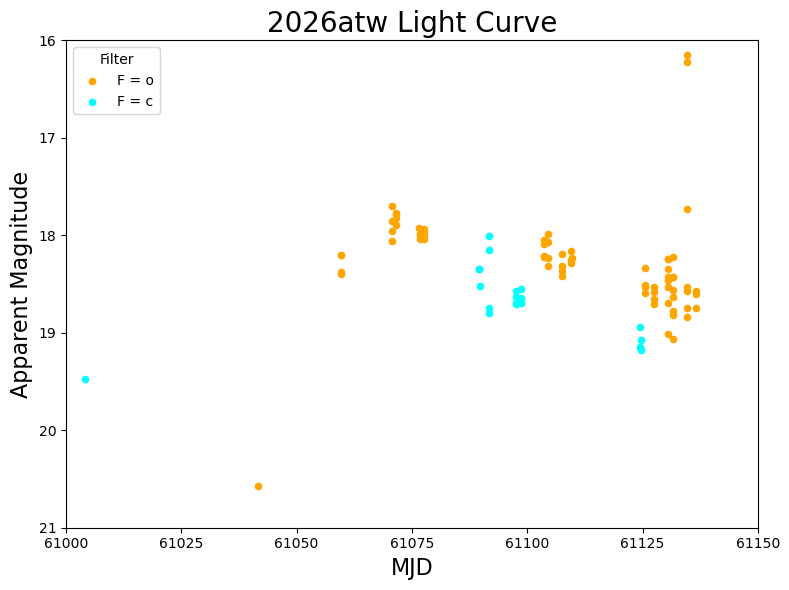

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Load file (no header in file)
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Assign correct column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean relevant columns
# --------------------------------------------------

# Fix filter column
df['F'] = df['F'].astype(str).str.strip()

# Ensure numeric types
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

# --------------------------------------------------
# 4. Quality cuts
# --------------------------------------------------

# Keep only valid magnitudes
df = df[df['m'] > 0]

# Remove NaNs
df = df.dropna(subset=['m', 'dm', 'F'])

# Signal-to-noise cut (SNR = 1 / error)
df = df[df['dm'] > 0]              # avoid divide-by-zero
df = df[(1 / df['dm']) >= 0.3]     # your requested threshold

# --------------------------------------------------
# 5. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 6. Plot light curve (CLEAN VERSION)
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.scatter(
        subset['MJD'].astype(float),
        subset['m'],
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        s=20
    )

# --------------------------------------------------
# 7. Final formatting (CLEANED AXES)
# --------------------------------------------------

plt.gca().invert_yaxis()

plt.xlabel("MJD", fontsize = 16)
plt.ylabel("Apparent Magnitude", fontsize = 16)
plt.title("2026atw Light Curve", fontsize = 20)

plt.legend(title="Filter")

# Remove grid
plt.grid(False)

# Cleaner ticks
plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

# Set axes
plt.xlim(left=61000, right=61150)
plt.ylim(top=16, bottom=21)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25946/1393255245.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Peak MJD: 61070.59
Assumed explosion MJD: 61060.59


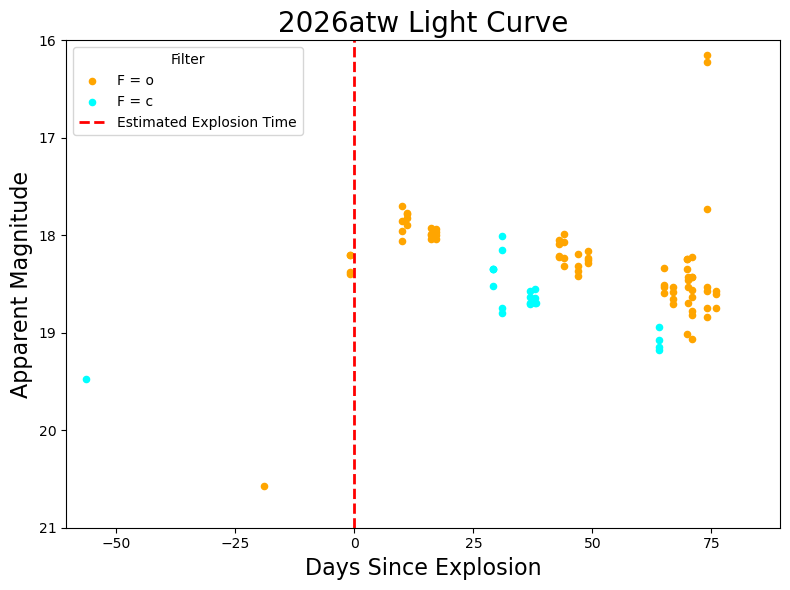

In [24]:
# --------------------------------------------------
# 1. Load file
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Assign column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean data
# --------------------------------------------------
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

df = df[df['m'] > 0]
df = df.dropna(subset=['MJD', 'm', 'dm', 'F'])

df = df[df['dm'] > 0]
df = df[(1 / df['dm']) >= 0.3]

# --------------------------------------------------
# 4. Find brightest point in window
# --------------------------------------------------
window = df[(df['MJD'] >= 61050) & (df['MJD'] <= 61075)]

if len(window) == 0:
    raise ValueError("No data in 61050–61075 window. Check cuts.")

peak_row = window.loc[window['m'].idxmin()]
MJD_peak = peak_row['MJD']

print(f"Peak MJD: {MJD_peak:.2f}")

# --------------------------------------------------
# 5. Define explosion BEFORE peak
# (adjust offset if needed)
# --------------------------------------------------
days_before_peak = 10   # <-- tweak this (e.g., 5–15 days typical)
MJD_explosion = MJD_peak - days_before_peak

print(f"Assumed explosion MJD: {MJD_explosion:.2f}")

# --------------------------------------------------
# 6. Convert to days since explosion
# --------------------------------------------------
df['t_days'] = df['MJD'] - MJD_explosion

# --------------------------------------------------
# 7. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 8. Plot
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.scatter(
        subset['t_days'],
        subset['m'],
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        s=20
    )

# --------------------------------------------------
# 9. Explosion line (day 0)
# --------------------------------------------------
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Estimated Explosion Time'
)

# --------------------------------------------------
# 10. Formatting
# --------------------------------------------------
plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)
plt.ylabel("Apparent Magnitude", fontsize=16)
plt.title("2026atw Light Curve", fontsize=20)

plt.legend(title="Filter")
plt.grid(False)

# Convert your original MJD limits → day limits
xmin = 61000 - MJD_explosion
xmax = 61150 - MJD_explosion

plt.xlim(xmin, xmax)
plt.ylim(top=16, bottom=21)

plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25946/1096062416.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Peak MJD: 61070.59
Assumed explosion MJD: 61060.59
Distance modulus: 35.32


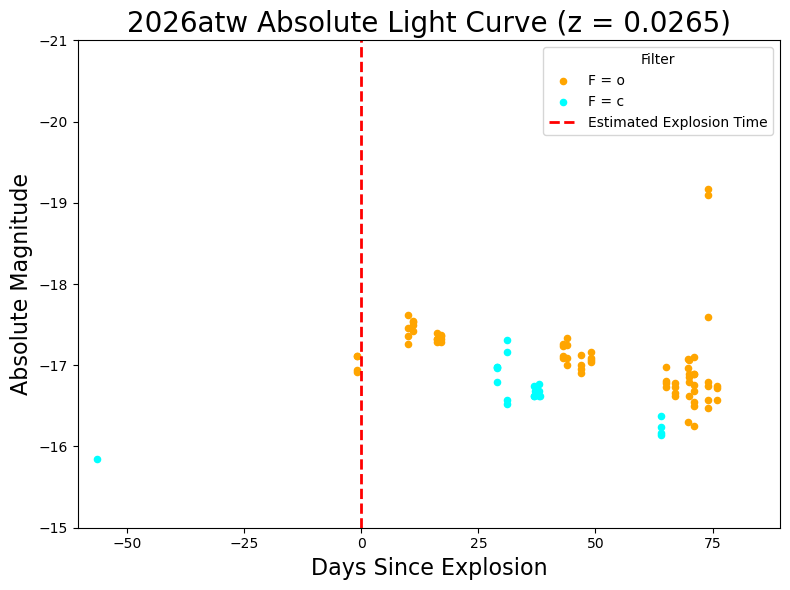

In [26]:
from astropy.cosmology import FlatLambdaCDM

# --------------------------------------------------
# 1. Load file
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean data
# --------------------------------------------------
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

df = df[df['m'] > 0]
df = df.dropna(subset=['MJD', 'm', 'dm', 'F'])

df = df[df['dm'] > 0]
df = df[(1 / df['dm']) >= 0.3]

# --------------------------------------------------
# 4. Find peak brightness (proxy for explosion anchor)
# --------------------------------------------------
window = df[(df['MJD'] >= 61050) & (df['MJD'] <= 61075)]

if len(window) == 0:
    raise ValueError("No data in explosion window 61050–61075.")

peak_row = window.loc[window['m'].idxmin()]
MJD_peak = peak_row['MJD']

# Assume explosion occurs before peak
days_before_peak = 10
MJD_explosion = MJD_peak - days_before_peak

print(f"Peak MJD: {MJD_peak:.2f}")
print(f"Assumed explosion MJD: {MJD_explosion:.2f}")

# --------------------------------------------------
# 5. Convert time axis (days since explosion)
# --------------------------------------------------
df['t_days'] = df['MJD'] - MJD_explosion

# --------------------------------------------------
# 6. Cosmology for absolute magnitude
# --------------------------------------------------
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 0.0265

D_L = cosmo.luminosity_distance(z).to('pc').value
mu = 5 * np.log10(D_L / 10)

print(f"Distance modulus: {mu:.2f}")

df['M_abs'] = df['m'] - mu

# --------------------------------------------------
# 7. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 8. Plot light curve
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.scatter(
        subset['t_days'],
        subset['M_abs'],
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        s=20
    )

# --------------------------------------------------
# 9. Explosion marker (day 0)
# --------------------------------------------------
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Estimated Explosion Time'
)

# --------------------------------------------------
# 10. Formatting
# --------------------------------------------------
plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)
plt.ylabel("Absolute Magnitude", fontsize=16)
plt.title("2026atw Absolute Light Curve (z = 0.0265)", fontsize=20)

plt.legend(title="Filter")
plt.grid(False)

# Convert original MJD window → day window
xmin = 61000 - MJD_explosion
xmax = 61150 - MJD_explosion

plt.xlim(xmin, xmax)

# Proper absolute magnitude axis (bright at top)
plt.ylim(bottom=-21, top=-15)
plt.gca().invert_yaxis()

plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25946/2345792668.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Peak MJD: 61070.59
Assumed explosion MJD: 61060.59
Distance modulus: 35.32


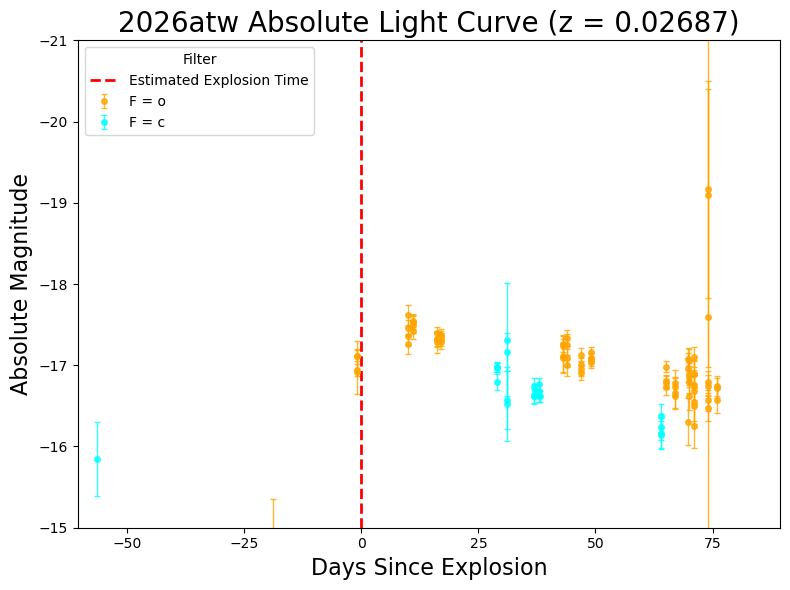

In [27]:
# --------------------------------------------------
# 1. Load file
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean data
# --------------------------------------------------
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

df = df[df['m'] > 0]
df = df.dropna(subset=['MJD', 'm', 'dm', 'F'])

df = df[df['dm'] > 0]
df = df[(1 / df['dm']) >= 0.3]

# --------------------------------------------------
# 4. Find peak brightness (explosion anchor proxy)
# --------------------------------------------------
window = df[(df['MJD'] >= 61050) & (df['MJD'] <= 61075)]

if len(window) == 0:
    raise ValueError("No data in explosion window 61050–61075.")

peak_row = window.loc[window['m'].idxmin()]
MJD_peak = peak_row['MJD']

# Explosion assumed before peak
days_before_peak = 10
MJD_explosion = MJD_peak - days_before_peak

print(f"Peak MJD: {MJD_peak:.2f}")
print(f"Assumed explosion MJD: {MJD_explosion:.2f}")

# --------------------------------------------------
# 5. Time axis (days since explosion)
# --------------------------------------------------
df['t_days'] = df['MJD'] - MJD_explosion

# --------------------------------------------------
# 6. Cosmology → absolute magnitude
# --------------------------------------------------
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 0.0265

D_L = cosmo.luminosity_distance(z).to('pc').value
mu = 5 * np.log10(D_L / 10)

print(f"Distance modulus: {mu:.2f}")

df['M_abs'] = df['m'] - mu

# --------------------------------------------------
# 7. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 8. Plot light curve WITH ERROR BARS
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.errorbar(
        subset['t_days'],
        subset['M_abs'],
        yerr=subset['dm'],
        fmt='o',
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        markersize=4,
        elinewidth=1,
        capsize=2,
        alpha=0.8
    )

# --------------------------------------------------
# 9. Explosion marker (day 0)
# --------------------------------------------------
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Estimated Explosion Time'
)

# --------------------------------------------------
# 10. Formatting
# --------------------------------------------------
plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)
plt.ylabel("Absolute Magnitude", fontsize=16)
plt.title("2026atw Absolute Light Curve (z = 0.0265)", fontsize=20)

plt.legend(title="Filter")
plt.grid(False)

# Convert original MJD window → day window
xmin = 61000 - MJD_explosion
xmax = 61150 - MJD_explosion

plt.xlim(xmin, xmax)

# Absolute magnitude range (bright at top)
plt.ylim(-15, -21)

plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25946/3666271568.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Peak MJD: 61070.59
Explosion MJD (forced): 61057.59
Distance modulus: 35.35


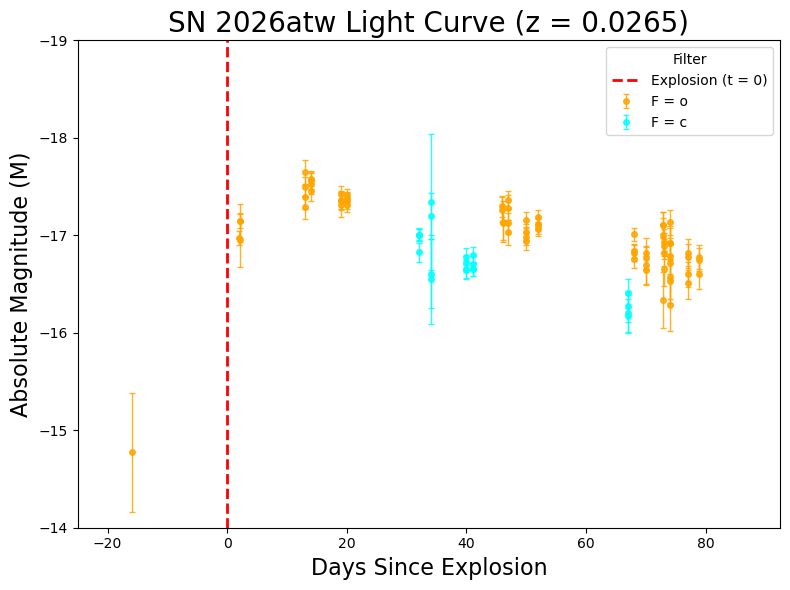

In [35]:
# --------------------------------------------------
# 1. Load file
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

# --------------------------------------------------
# 2. Column names
# --------------------------------------------------
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 3. Clean data
# --------------------------------------------------
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')

df = df[df['m'] > 0]
df = df.dropna(subset=['MJD', 'm', 'dm', 'F'])

# --------------------------------------------------
# 4. STRONGER S/N CUT (removes huge error bars)
# --------------------------------------------------
df = df[df['dm'] > 0]
df = df[(1 / df['dm']) >= 1.0]   # stricter than before (was 0.3)

# --------------------------------------------------
# 5. Define explosion time = fixed offset (-13 days)
# --------------------------------------------------
# First find a reference anchor (peak window as before)
window = df[(df['MJD'] >= 61050) & (df['MJD'] <= 61075)]

peak_row = window.loc[window['m'].idxmin()]
MJD_peak = peak_row['MJD']

# Force explosion 13 days before peak
MJD_explosion = MJD_peak - 13

print(f"Peak MJD: {MJD_peak:.2f}")
print(f"Explosion MJD (forced): {MJD_explosion:.2f}")

# --------------------------------------------------
# 6. Time axis (shift so explosion = Day 0)
# --------------------------------------------------
df['t_days'] = df['MJD'] - MJD_explosion

# --------------------------------------------------
# 7. Cosmology → absolute magnitude
# --------------------------------------------------
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 0.02687

D_L = cosmo.luminosity_distance(z).to('pc').value
mu = 5 * np.log10(D_L / 10)

df['M_abs'] = df['m'] - mu

print(f"Distance modulus: {mu:.2f}")

# --------------------------------------------------
# 8. Color mapping
# --------------------------------------------------
color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# --------------------------------------------------
# 9. Plot WITH error bars (cleaned data)
# --------------------------------------------------
plt.figure(figsize=(8,6))

for filt in df['F'].unique():
    subset = df[df['F'] == filt]

    plt.errorbar(
        subset['t_days'],
        subset['M_abs'],
        yerr=subset['dm'],
        fmt='o',
        color=color_map.get(filt, 'black'),
        label=f"F = {filt}",
        markersize=4,
        elinewidth=1,
        capsize=2,
        alpha=0.85
    )

# --------------------------------------------------
# 10. Explosion marker (NOW FIXED at Day 0 = -13 shift)
# --------------------------------------------------
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Explosion (t = 0)'
)

# --------------------------------------------------
# 11. Formatting
# --------------------------------------------------
plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)
plt.ylabel("Absolute Magnitude (M)", fontsize=16)
plt.title("SN 2026atw Light Curve (z = 0.0265)", fontsize=20)

plt.legend(title="Filter")
plt.grid(False)

# Axis limits in new frame
xmin = (61000 - MJD_explosion)
xmax = (61150 - MJD_explosion)

plt.xlim(-25, xmax)

plt.ylim(-14, -19)

plt.locator_params(axis='x', nbins=6)
plt.locator_params(axis='y', nbins=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25946/937795136.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)
/tmp/ipykernel_25946/937795136.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


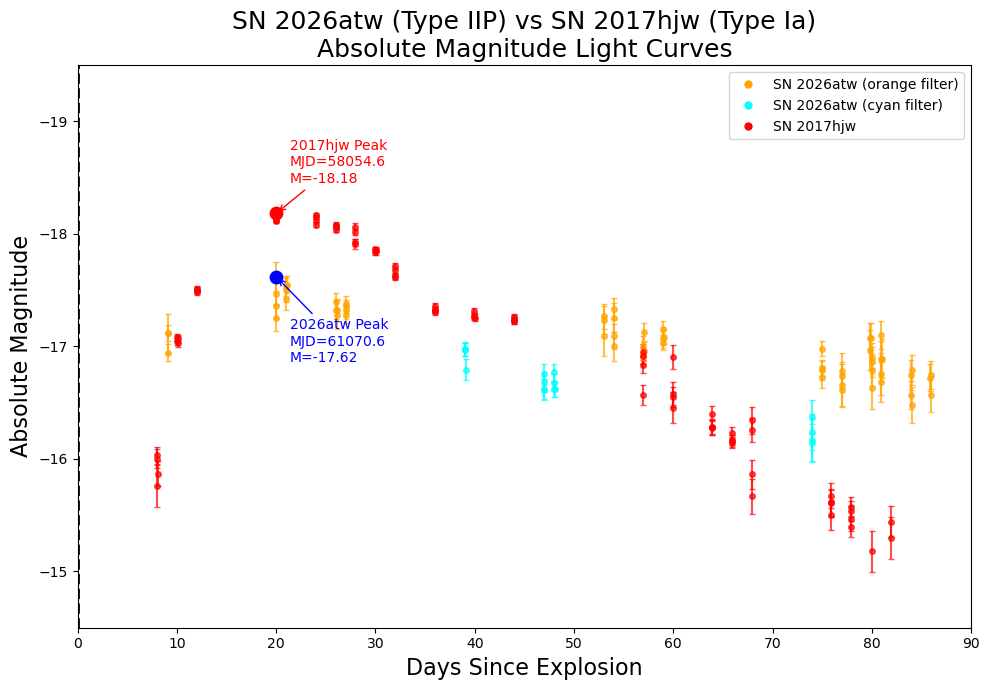

In [31]:
# ============================================================
# COSMOLOGY
# ============================================================

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# ============================================================
# LOAD + CLEAN FUNCTION
# ============================================================

def load_lightcurve(url):

    df = pd.read_csv(url, delim_whitespace=True, header=None)

    df.columns = [
        "MJD", "m", "dm", "uJy", "duJy", "F",
        "err", "chi_N", "RA", "Dec",
        "x", "y", "maj", "min",
        "phi", "apfit", "mag5sig", "Sky",
        "Obs"
    ]

    for col in ['MJD', 'm', 'dm', 'uJy', 'duJy']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['F'] = df['F'].astype(str).str.strip()

    df = df.dropna(subset=['MJD', 'm', 'dm', 'uJy', 'duJy'])

    df = df[df['m'] > 0]
    df = df[df['dm'] > 0]

    df['SNR'] = df['uJy'] / df['duJy']
    df = df[df['SNR'] >= 5]

    return df

# ============================================================
# PROCESS FUNCTION
# ============================================================

def process_sn(df, z, rise_time=20):

    peak_row = df.loc[df['m'].idxmin()]
    MJD_peak = peak_row['MJD']

    MJD_explosion = MJD_peak - rise_time

    df = df.copy()
    df['t_days'] = df['MJD'] - MJD_explosion

    mu = 5 * np.log10(cosmo.luminosity_distance(z).to('pc').value / 10)
    df['M_abs'] = df['m'] - mu

    return df, MJD_peak, MJD_explosion, mu

# ============================================================
# LOAD DATA
# ============================================================

url_atw = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
url_hjw = "https://fallingstar-data.com/forcedphot/static/results/job4246300.txt"

df_atw = load_lightcurve(url_atw)
df_hjw = load_lightcurve(url_hjw)

# ✔ CORRECT REDSHIFTS
df_atw, peak_atw, exp_atw, mu_atw = process_sn(df_atw, z=0.0265)
df_hjw, peak_hjw, exp_hjw, mu_hjw = process_sn(df_hjw, z=0.016161)

# ============================================================
# PEAK VALUES
# ============================================================

atw_peak = df_atw.loc[df_atw['M_abs'].idxmin()]
hjw_peak = df_hjw.loc[df_hjw['M_abs'].idxmin()]

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10,7))

# -------------------------
# ATW (ORANGE + CYAN SWAPPED FIX)
# -------------------------

atw_filters = list(df_atw['F'].unique())
atw_colors = ['orange', 'cyan']

for i, filt in enumerate(atw_filters):

    sub = df_atw[df_atw['F'] == filt]

    ax.errorbar(
        sub['t_days'],
        sub['M_abs'],
        yerr=sub['dm'],
        fmt='o',
        color=atw_colors[i % len(atw_colors)],
        alpha=0.7,
        markersize=4,
        capsize=2,
        label='SN 2026atw' if i == 0 else ""
    )

# -------------------------
# HJW (RED)
# -------------------------

for i, filt in enumerate(df_hjw['F'].unique()):

    sub = df_hjw[df_hjw['F'] == filt]

    ax.errorbar(
        sub['t_days'],
        sub['M_abs'],
        yerr=sub['dm'],
        fmt='o',
        color='red',
        alpha=0.7,
        markersize=4,
        capsize=2,
        label='SN 2017hjw' if i == 0 else ""
    )

# ============================================================
# SAFE ANNOTATION FUNCTION
# ============================================================

def safe_annotate(ax, x, y, text, color):

    ax.scatter(x, y, color=color, s=80, zorder=5, clip_on=True)

    if y < -18:
        voffset = 20
        va = "bottom"
    else:
        voffset = -30
        va = "top"

    ax.annotate(
        text,
        xy=(x, y),
        xytext=(10, voffset),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->", color=color, lw=1),
        color=color,
        fontsize=10,
        ha="left",
        va=va,
        clip_on=True
    )

# -------------------------
# PEAK ANNOTATIONS
# -------------------------

safe_annotate(
    ax,
    atw_peak['t_days'],
    atw_peak['M_abs'],
    f"2026atw Peak\nMJD={atw_peak['MJD']:.1f}\nM={atw_peak['M_abs']:.2f}",
    "blue"
)

safe_annotate(
    ax,
    hjw_peak['t_days'],
    hjw_peak['M_abs'],
    f"2017hjw Peak\nMJD={hjw_peak['MJD']:.1f}\nM={hjw_peak['M_abs']:.2f}",
    "red"
)

# ============================================================
# EXPLOSION MARKER
# ============================================================

ax.axvline(0, color='black', linestyle='--', linewidth=2)

# ============================================================
# FORMATTING
# ============================================================

ax.set_xlabel("Days Since Explosion", fontsize=16)
ax.set_ylabel("Absolute Magnitude", fontsize=16)

ax.invert_yaxis()

ax.set_title(
    "SN 2026atw (Type IIP) vs SN 2017hjw (Type Ia)\nAbsolute Magnitude Light Curves",
    fontsize=18
)

ax.set_xlim(0, 90)
ax.set_ylim(-14.5, -19.5)

from matplotlib.lines import Line2D
 
legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='SN 2026atw (orange filter)',
        markerfacecolor='orange',
        markersize=7
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='SN 2026atw (cyan filter)',
        markerfacecolor='cyan',
        markersize=7
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='SN 2017hjw',
        markerfacecolor='red',
        markersize=7
    )
]

ax.legend(handles=legend_elements)

ax.grid(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25946/2941406811.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)
/tmp/ipykernel_25946/2941406811.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


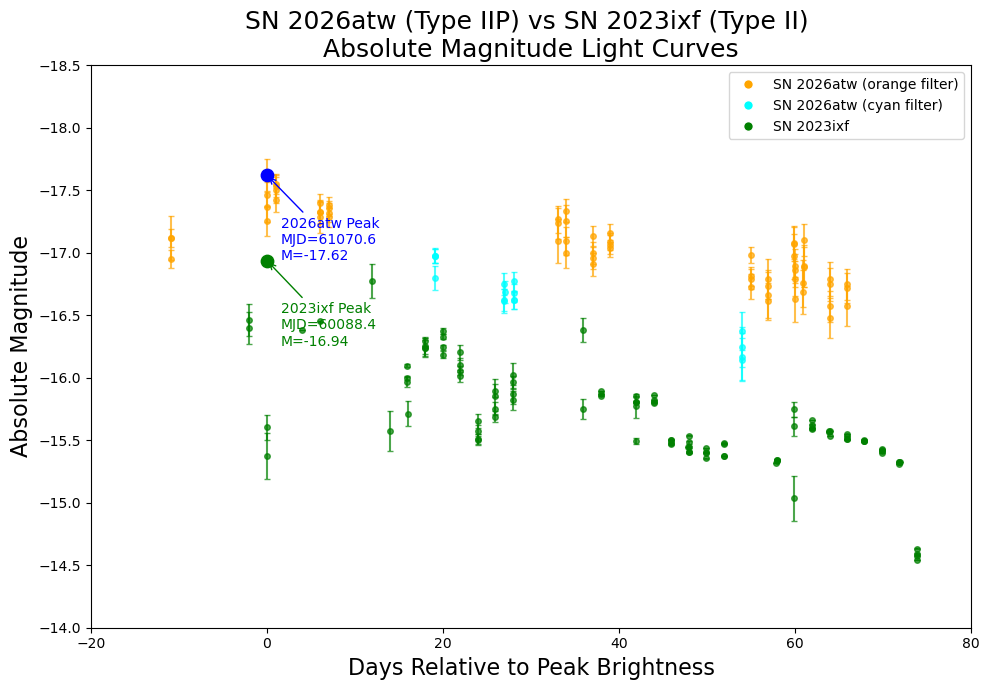

In [32]:
# ============================================================
# COSMOLOGY
# ============================================================

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# ============================================================
# LOAD + CLEAN FUNCTION
# ============================================================

def load_lightcurve(url):

    df = pd.read_csv(url, delim_whitespace=True, header=None)

    df.columns = [
        "MJD", "m", "dm", "uJy", "duJy", "F",
        "err", "chi_N", "RA", "Dec",
        "x", "y", "maj", "min",
        "phi", "apfit", "mag5sig", "Sky",
        "Obs"
    ]

    for col in ['MJD', 'm', 'dm', 'uJy', 'duJy']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    df['F'] = df['F'].astype(str).str.strip()

    df = df.dropna(subset=['MJD', 'm', 'dm', 'uJy', 'duJy'])

    df = df[df['m'] > 0]
    df = df[df['dm'] > 0]

    # Signal-to-noise cut
    df['SNR'] = df['uJy'] / df['duJy']
    df = df[df['SNR'] >= 5]

    return df

# ============================================================
# PROCESS FUNCTION
# ============================================================

def process_sn(df, z, explosion_mjd):

    df = df.copy()

    # Time since explosion
    df['t_days'] = df['MJD'] - explosion_mjd

    # Distance modulus
    mu = 5 * np.log10(
        cosmo.luminosity_distance(z).to('pc').value / 10
    )

    # Absolute magnitude
    df['M_abs'] = df['m'] - mu

    return df, mu

# ============================================================
# LOAD DATA
# ============================================================

url_atw = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
url_ixf = "https://fallingstar-data.com/forcedphot/static/results/job4250096.txt"

df_atw = load_lightcurve(url_atw)
df_ixf = load_lightcurve(url_ixf)

# ============================================================
# PROCESS SUPERNOVAE
# ============================================================

# -------------------------
# SN 2026atw
# -------------------------

peak_row_atw = df_atw.loc[df_atw['m'].idxmin()]
peak_mjd_atw = peak_row_atw['MJD']

rise_time_atw = 20
explosion_mjd_atw = peak_mjd_atw - rise_time_atw

df_atw, mu_atw = process_sn(
    df_atw,
    z=0.0265,
    explosion_mjd=explosion_mjd_atw
)

# -------------------------
# SN 2023ixf
# -------------------------

explosion_mjd_ixf = 60050

df_ixf, mu_ixf = process_sn(
    df_ixf,
    z=0.0008,
    explosion_mjd=explosion_mjd_ixf
)

# ============================================================
# FIND PEAKS
# ============================================================

atw_peak = df_atw.loc[df_atw['M_abs'].idxmin()]
ixf_peak = df_ixf.loc[df_ixf['M_abs'].idxmin()]

# ============================================================
# ALIGN PEAKS
# ============================================================

# Shift each SN so that peak occurs at t = 0

df_atw['t_aligned'] = df_atw['t_days'] - atw_peak['t_days']
df_ixf['t_aligned'] = df_ixf['t_days'] - ixf_peak['t_days']

# Updated peak positions after alignment
atw_peak_x = 0
ixf_peak_x = 0

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(10, 7))

# --------------------------------------------------
# SN 2026atw (orange + cyan)
# --------------------------------------------------

atw_filters = list(df_atw['F'].unique())
atw_colors = ['orange', 'cyan']

for i, filt in enumerate(atw_filters):

    sub = df_atw[df_atw['F'] == filt]

    ax.errorbar(
        sub['t_aligned'],
        sub['M_abs'],
        yerr=sub['dm'],
        fmt='o',
        color=atw_colors[i % len(atw_colors)],
        alpha=0.7,
        markersize=4,
        capsize=2,
        label='SN 2026atw' if i == 0 else ""
    )

# --------------------------------------------------
# SN 2023ixf (green)
# --------------------------------------------------

for i, filt in enumerate(df_ixf['F'].unique()):

    sub = df_ixf[df_ixf['F'] == filt]

    ax.errorbar(
        sub['t_aligned'],
        sub['M_abs'],
        yerr=sub['dm'],
        fmt='o',
        color='green',
        alpha=0.7,
        markersize=4,
        capsize=2,
        label='SN 2023ixf' if i == 0 else ""
    )

# ============================================================
# SAFE ANNOTATION FUNCTION
# ============================================================

def safe_annotate(ax, x, y, text, color):

    ax.scatter(
        x,
        y,
        color=color,
        s=80,
        zorder=5,
        clip_on=True
    )

    if y < -18:
        voffset = 20
        va = "bottom"
    else:
        voffset = -30
        va = "top"

    ax.annotate(
        text,
        xy=(x, y),
        xytext=(10, voffset),
        textcoords="offset points",
        arrowprops=dict(
            arrowstyle="->",
            color=color,
            lw=1
        ),
        color=color,
        fontsize=10,
        ha="left",
        va=va,
        clip_on=True
    )

# ============================================================
# PEAK ANNOTATIONS
# ============================================================

safe_annotate(
    ax,
    atw_peak_x,
    atw_peak['M_abs'],
    f"2026atw Peak\nMJD={atw_peak['MJD']:.1f}\nM={atw_peak['M_abs']:.2f}",
    "blue"
)

safe_annotate(
    ax,
    ixf_peak_x,
    ixf_peak['M_abs'],
    f"2023ixf Peak\nMJD={ixf_peak['MJD']:.1f}\nM={ixf_peak['M_abs']:.2f}",
    "green"
)

# ============================================================
# FORMATTING
# ============================================================

ax.set_xlabel(
    "Days Relative to Peak Brightness",
    fontsize=16
)

ax.set_ylabel(
    "Absolute Magnitude",
    fontsize=16
)

ax.invert_yaxis()

ax.set_title(
    "SN 2026atw (Type IIP) vs SN 2023ixf (Type II) \nAbsolute Magnitude Light Curves",
    fontsize=18
)

ax.set_xlim(-20, 80)
ax.set_ylim(-14, -18.5)

# ============================================================
# CUSTOM LEGEND
# ============================================================

from matplotlib.lines import Line2D

legend_elements = [

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='SN 2026atw (orange filter)',
        markerfacecolor='orange',
        markersize=7
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='SN 2026atw (cyan filter)',
        markerfacecolor='cyan',
        markersize=7
    ),

    Line2D(
        [0], [0],
        marker='o',
        color='w',
        label='SN 2023ixf',
        markerfacecolor='green',
        markersize=7
    )
]

ax.legend(handles=legend_elements)

ax.grid(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_25946/17704525.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)


Estimated Peak MJD: 61070.59 ± 0.01
Peak magnitude: 17.70 ± 0.13

Estimated Explosion MJD: 61050.59 ± 5.00
Latest observation MJD: 61136.51 ± 0.01
Estimated SN age: 85.9 ± 5.0 days
Distance modulus: 35.32 ± 0.008
Peak absolute magnitude: -17.62 ± 0.13


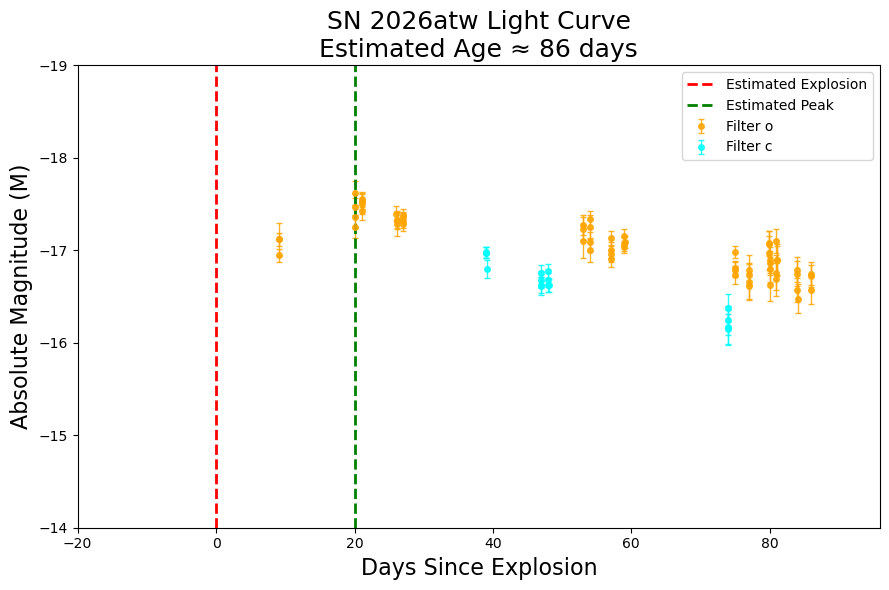


FINAL ESTIMATED PHASE
Explosion MJD : 61050.59 ± 5.00
Peak MJD      : 61070.59 ± 0.01
Peak Mag      : 17.70 ± 0.13
Peak Abs Mag  : -17.62 ± 0.13
Rise Time     : 20.0 ± 5.0 days
Current Age   : 85.9 ± 5.0 days
Distance Modulus : 35.32 ± 0.008


In [33]:
# =========================================================
# 1. Load file
# =========================================================
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"

df = pd.read_csv(url, delim_whitespace=True, header=None)

# =========================================================
# 2. Column names
# =========================================================
df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# =========================================================
# 3. Clean data
# =========================================================
df['F'] = df['F'].astype(str).str.strip()

df['MJD'] = pd.to_numeric(df['MJD'], errors='coerce')
df['m'] = pd.to_numeric(df['m'], errors='coerce')
df['dm'] = pd.to_numeric(df['dm'], errors='coerce')
df['uJy'] = pd.to_numeric(df['uJy'], errors='coerce')
df['duJy'] = pd.to_numeric(df['duJy'], errors='coerce')

df = df[df['m'] > 0]

df = df.dropna(subset=['MJD', 'm', 'dm', 'uJy', 'duJy'])

# =========================================================
# 4. Strong S/N cut
# =========================================================
df = df[df['dm'] > 0]

# Strong detections only
df['SNR'] = df['uJy'] / df['duJy']

df = df[df['SNR'] >= 5]

# =========================================================
# 5. FIND PEAK DIRECTLY FROM LIGHT CURVE
# =========================================================

# brightest point = minimum magnitude
peak_row = df.loc[df['m'].idxmin()]

MJD_peak = peak_row['MJD']
peak_mag = peak_row['m']

# Measured uncertainty from photometry
peak_mag_unc = peak_row['dm']

# Estimate timing uncertainty from cadence
sorted_df = df.sort_values('MJD')

mjds = sorted_df['MJD'].values

if len(mjds) > 2:
    cadence = np.median(np.diff(mjds))
else:
    cadence = 1.0

MJD_peak_unc = cadence / 2

print("================================================")
print(f"Estimated Peak MJD: {MJD_peak:.2f} ± {MJD_peak_unc:.2f}")
print(f"Peak magnitude: {peak_mag:.2f} ± {peak_mag_unc:.2f}")

# =========================================================
# 6. ESTIMATE EXPLOSION DATE
# =========================================================
#
# Typical stripped-envelope SNe:
# rise time ≈ 15–25 days
#
# Adopt:
# rise time = 20 ± 5 days
# =========================================================

rise_time_estimate = 20.0
rise_time_unc = 5.0

MJD_explosion = MJD_peak - rise_time_estimate

# Propagate uncertainty
MJD_explosion_unc = np.sqrt(
    MJD_peak_unc**2 +
    rise_time_unc**2
)

print(
    f"\nEstimated Explosion MJD: "
    f"{MJD_explosion:.2f} ± {MJD_explosion_unc:.2f}"
)

# =========================================================
# 7. COMPUTE DAYS SINCE EXPLOSION
# =========================================================

df['t_days'] = df['MJD'] - MJD_explosion

# =========================================================
# 8. CURRENT SUPERNOVA AGE
# =========================================================

latest_obs = df['MJD'].max()

current_age = latest_obs - MJD_explosion

# Estimate uncertainty in latest observation time
latest_obs_unc = cadence / 2

# Propagate uncertainty
current_age_unc = np.sqrt(
    latest_obs_unc**2 +
    MJD_explosion_unc**2
)

print(
    f"Latest observation MJD: "
    f"{latest_obs:.2f} ± {latest_obs_unc:.2f}"
)

print(
    f"Estimated SN age: "
    f"{current_age:.1f} ± {current_age_unc:.1f} days"
)

# =========================================================
# 9. Cosmology → absolute magnitude
# =========================================================

cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

z = 0.0265
z_unc = 0.00010

D_L = cosmo.luminosity_distance(z).to('pc').value

mu = 5 * np.log10(D_L / 10)

# Approximate uncertainty propagation:
#
# sigma_mu ≈ (5/ln(10)) * (sigma_z/z)

mu_unc = (5 / np.log(10)) * (z_unc / z)

df['M_abs'] = df['m'] - mu

print(f"Distance modulus: {mu:.2f} ± {mu_unc:.3f}")

# =========================================================
# 10. Peak absolute magnitude uncertainty
# =========================================================

peak_abs_mag = peak_mag - mu

peak_abs_mag_unc = np.sqrt(
    peak_mag_unc**2 +
    mu_unc**2
)

print(
    f"Peak absolute magnitude: "
    f"{peak_abs_mag:.2f} ± {peak_abs_mag_unc:.2f}"
)

# =========================================================
# 11. Color mapping
# =========================================================

color_map = {
    'o': 'orange',
    'c': 'cyan'
}

# =========================================================
# 12. Plot (UNCHANGED)
# =========================================================

plt.figure(figsize=(9,6))

for filt in df['F'].unique():

    subset = df[df['F'] == filt]

    plt.errorbar(
        subset['t_days'],
        subset['M_abs'],
        yerr=subset['dm'],
        fmt='o',
        color=color_map.get(filt, 'black'),
        label=f"Filter {filt}",
        markersize=4,
        elinewidth=1,
        capsize=2,
        alpha=0.85
    )

# Explosion marker
plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Estimated Explosion'
)

# Peak marker
plt.axvline(
    x=rise_time_estimate,
    color='green',
    linestyle='--',
    linewidth=2,
    label='Estimated Peak'
)

# =========================================================
# 13. Formatting
# =========================================================

plt.gca().invert_yaxis()

plt.xlabel("Days Since Explosion", fontsize=16)

plt.ylabel("Absolute Magnitude (M)", fontsize=16)

plt.title(
    f"SN 2026atw Light Curve\nEstimated Age ≈ {current_age:.0f} days",
    fontsize=18
)

plt.legend()

plt.grid(False)

plt.xlim(-20, current_age + 10)

plt.ylim(-14, -19)

plt.locator_params(axis='x', nbins=7)

plt.locator_params(axis='y', nbins=6)

plt.tight_layout()

plt.show()

# =========================================================
# 14. FINAL SUMMARY
# =========================================================

print("\n================================================")
print("FINAL ESTIMATED PHASE")
print("================================================")

print(
    f"Explosion MJD : "
    f"{MJD_explosion:.2f} ± {MJD_explosion_unc:.2f}"
)

print(
    f"Peak MJD      : "
    f"{MJD_peak:.2f} ± {MJD_peak_unc:.2f}"
)

print(
    f"Peak Mag      : "
    f"{peak_mag:.2f} ± {peak_mag_unc:.2f}"
)

print(
    f"Peak Abs Mag  : "
    f"{peak_abs_mag:.2f} ± {peak_abs_mag_unc:.2f}"
)

print(
    f"Rise Time     : "
    f"{rise_time_estimate:.1f} ± {rise_time_unc:.1f} days"
)

print(
    f"Current Age   : "
    f"{current_age:.1f} ± {current_age_unc:.1f} days"
)

print(
    f"Distance Modulus : "
    f"{mu:.2f} ± {mu_unc:.3f}"
)

print("================================================")

In [34]:
# --------------------------------------------------
# 1. Load data
# --------------------------------------------------
url = "https://fallingstar-data.com/forcedphot/static/results/job4191215.txt"
df = pd.read_csv(url, delim_whitespace=True, header=None)

df.columns = [
    "MJD", "m", "dm", "uJy", "duJy", "F",
    "err", "chi_N", "RA", "Dec",
    "x", "y", "maj", "min",
    "phi", "apfit", "mag5sig", "Sky",
    "Obs"
]

# --------------------------------------------------
# 2. Clean data
# --------------------------------------------------
df["MJD"] = pd.to_numeric(df["MJD"], errors="coerce")
df["m"] = pd.to_numeric(df["m"], errors="coerce")
df["dm"] = pd.to_numeric(df["dm"], errors="coerce")
df = df.dropna(subset=["MJD", "m", "dm"])
df = df[(df["m"] > 0) & (df["dm"] > 0)]

# --------------------------------------------------
# 3. Peak brightness from data
# --------------------------------------------------
idx_peak = df["m"].idxmin()

m_peak = df.loc[idx_peak, "m"]
dm_peak = df.loc[idx_peak, "dm"]
t_peak = df.loc[idx_peak, "MJD"]

# --------------------------------------------------
# 4. Redshift of SN
# --------------------------------------------------
z_sn = 0.02687
c = 299792.458  # km/s

# --------------------------------------------------
# 5. Hubble constant + uncertainty
# --------------------------------------------------
H0 = 70.0
H0_unc = 2.0

# Peculiar velocity uncertainty (dominant at low z)
v_pec = 300  # km/s

# --------------------------------------------------
# 6. Distance from Hubble's Law
# --------------------------------------------------
v = c * z_sn
d_Mpc = v / H0

# Uncertainty propagation:
# σ_d from H0 + peculiar velocity
d_from_H0_unc = d_Mpc * (H0_unc / H0)
d_from_v_unc = v_pec / H0

d_Mpc_unc = np.sqrt(d_from_H0_unc**2 + d_from_v_unc**2)

# --------------------------------------------------
# 7. Distance modulus
# --------------------------------------------------
pc_per_Mpc = 1e6

d_pc = d_Mpc * pc_per_Mpc
d_pc_unc = d_Mpc_unc * pc_per_Mpc

mu = 5 * np.log10(d_pc) - 5

mu_unc = (5 / np.log(10)) * (d_pc_unc / d_pc)

# --------------------------------------------------
# 8. Peak absolute magnitude
# --------------------------------------------------
M_peak = m_peak - mu

M_peak_unc = np.sqrt(dm_peak**2 + mu_unc**2)

# --------------------------------------------------
# 9. Convert magnitude → luminosity
# --------------------------------------------------
M_sun = 4.83

L_ratio = 10 ** (-0.4 * (M_peak - M_sun))

# Propagate uncertainty in magnitude:
L_ratio_unc = L_ratio * (0.4 * np.log(10)) * M_peak_unc

# --------------------------------------------------
# 10. Output results
# --------------------------------------------------
print("\n================ RESULTS ================\n")

print(f"Peak MJD: {t_peak:.2f}")

print(f"Peak apparent magnitude: {m_peak:.3f} ± {dm_peak:.3f}")

print(f"Distance (Hubble law): {d_Mpc:.2f} ± {d_Mpc_unc:.2f} Mpc")

print(f"Distance modulus: {mu:.3f} ± {mu_unc:.3f}")

print(f"Peak absolute magnitude: {M_peak:.3f} ± {M_peak_unc:.3f}")

print(f"Peak luminosity (L/Lsun): {L_ratio:.3e} ± {L_ratio_unc:.3e}")

/tmp/ipykernel_25946/833279840.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, delim_whitespace=True, header=None)



================ RESULTS ================

Peak MJD: 60769.53
Peak apparent magnitude: 14.922 ± 0.659
Distance (Hubble law): 115.08 ± 5.40 Mpc
Distance modulus: 35.305 ± 0.102
Peak absolute magnitude: -20.383 ± 0.667
Peak luminosity (L/Lsun): 1.217e+10 ± 7.473e+09
